# Introduction
A **binary search** tree (BST) satisfies property:

1. The value in each node must be greater than (or equal to) any values stored in its left subtree.
2. The value in each node must be less than (or equal to) any values stored in its right subtree.

*it is noteworthy that inorder traversal in BST will be in ascending order*

The goal of this card is to:

1. Understand the properties of a binary tree;
2. Be able to do basic operations in a binary search tree;
3. Understand the concept of a height-balanced binary search tree.

## Inorder Successor in BST (Template)
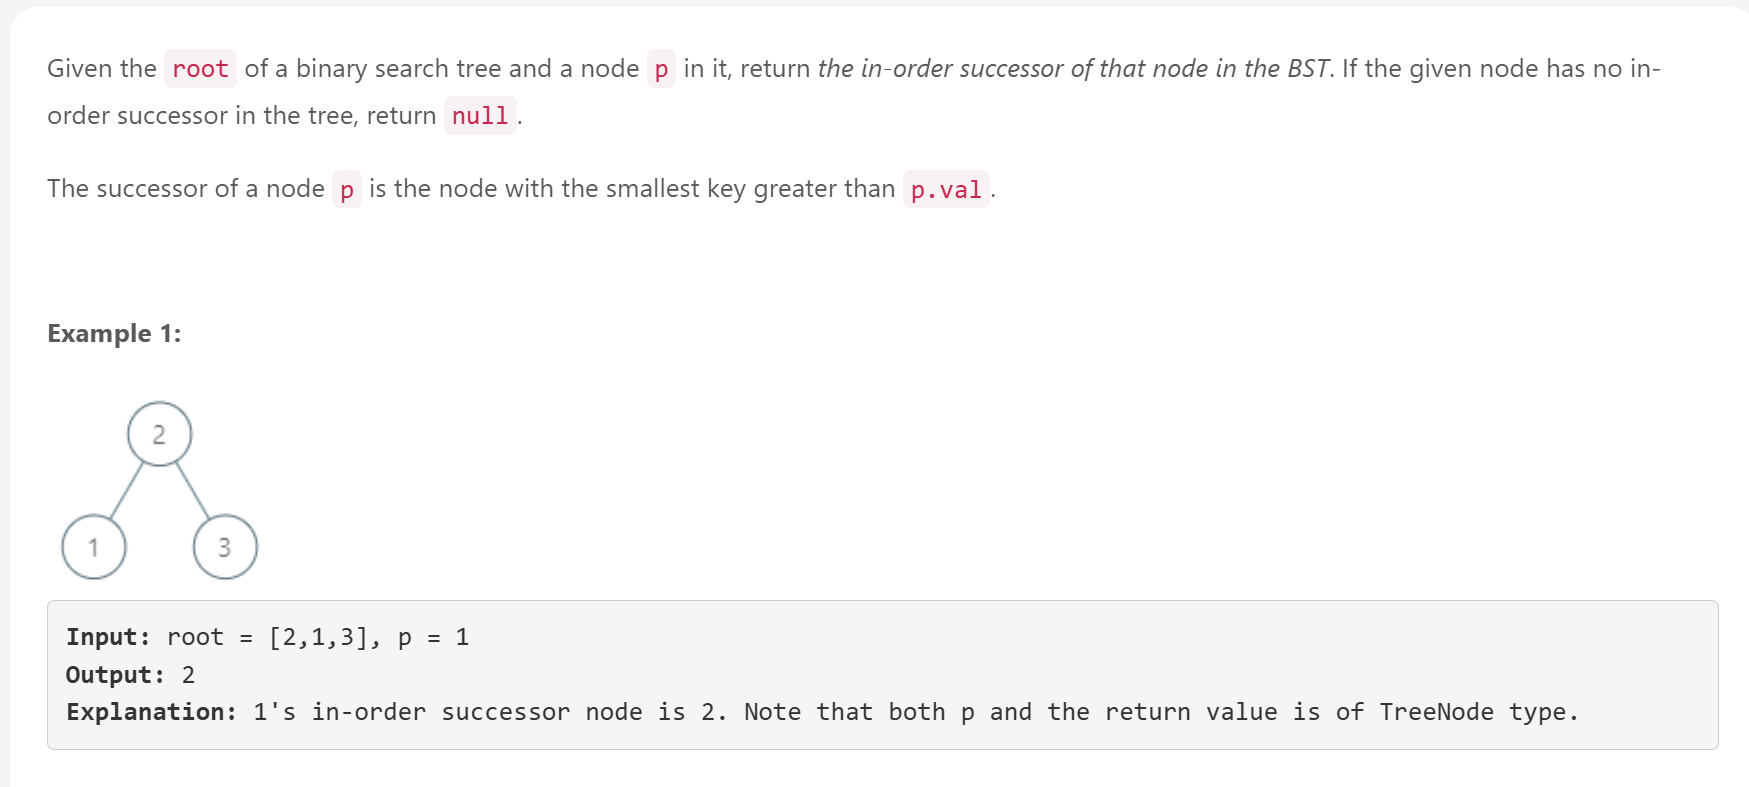
```python
class Solution:
    def inorderSuccessor(self, root: TreeNode, p: TreeNode) -> Optional[TreeNode]:
        # Typical trick is to store the previous node in the traversal 
        self.prev, self.ans = None, None
        
        def inorder(node):
            if not node or self.ans:
                return 
            
            inorder(node.left)
            
            if self.prev == p and self.ans is None:
                self.ans = node
                return 
            
            self.prev = node
                
            inorder(node.right)
        
        inorder(root)
        return self.ans
```

## Find the successor of a given node in a BST
```python
def successor(root: TreeNode) -> TreeNode:
    root = root.right
    while root.left:
        root = root.left
    return root
```

## Find the predecessor of a given node in a BST
```python   
def predecessor(root: TreeNode) -> TreeNode:
    root = root.left
    while root.right:
        root = root.right
    return root
```

# Search in a BST
BSTs support three main operations: search, insertion and deletion. The following shows how to search for a specific value in a BST.

For each node:

1. return the node if the target value is equal to the value of the node;
2. continue searching in the left subtree if the target value is less than the value of the node;
3. continue searching in the right subtree if the target value is larger than the value of the node.

Let's go through an example: we search for target = 4 in the BST above.
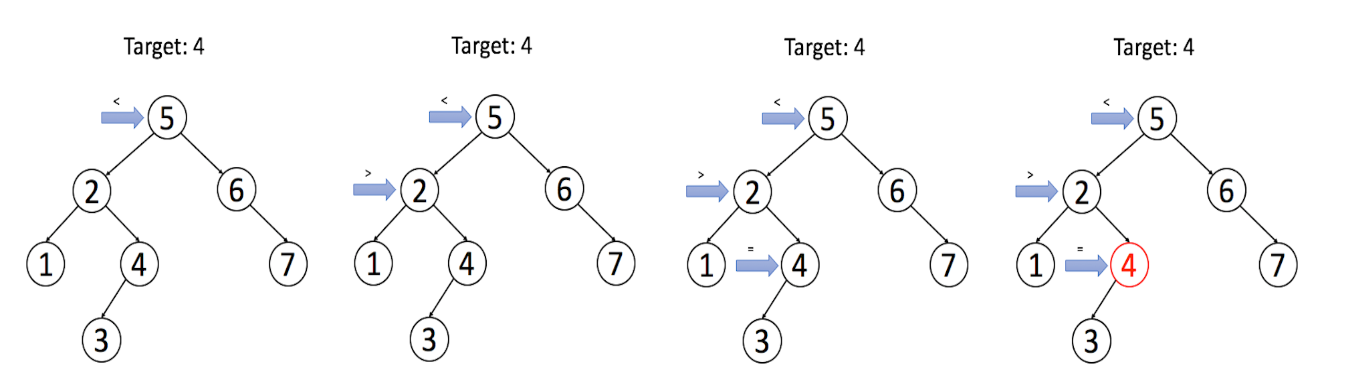


# 🔍 Search in a Binary Search Tree (BST)

## 🧠 Problem
Given the root of a Binary Search Tree (BST) and an integer `val`,  
return the node where the value equals `val`. If not found, return `None`.

---

## ✅ Approach 1: Recursive (利用 BST 性质)

### 思路
BST 满足：
- 左子树 < root
- 右子树 > root

所以可以：
- 小 → 去左边
- 大 → 去右边
- 等于 → 返回

### Code
```python
class Solution:
    def searchBST(self, root: Optional[TreeNode], val: int) -> Optional[TreeNode]:
        def dfs(node):
            if not node:
                return None
            
            if val == node.val:
                return node
            elif val < node.val:
                return dfs(node.left)
            else:
                return dfs(node.right)
        
        return dfs(root)

## ✅ Approach 2: Iterative (Stack / While Loop)
### 思路

其实不需要显式 stack，BST 可以直接 while 走路径：

一路向下走
每次只走一边（不像普通树要回溯）
```python
class Solution:
    def searchBST(self, root: Optional[TreeNode], val: int) -> Optional[TreeNode]:
        cur = root
        
        while cur:
            if val == cur.val:
                return cur
            elif val < cur.val:
                cur = cur.left
            else:
                cur = cur.right
        
        return None
```
⏱ Complexity
Time: O(h)
Space: O(1)

# Insertion in a Binary Search Tree
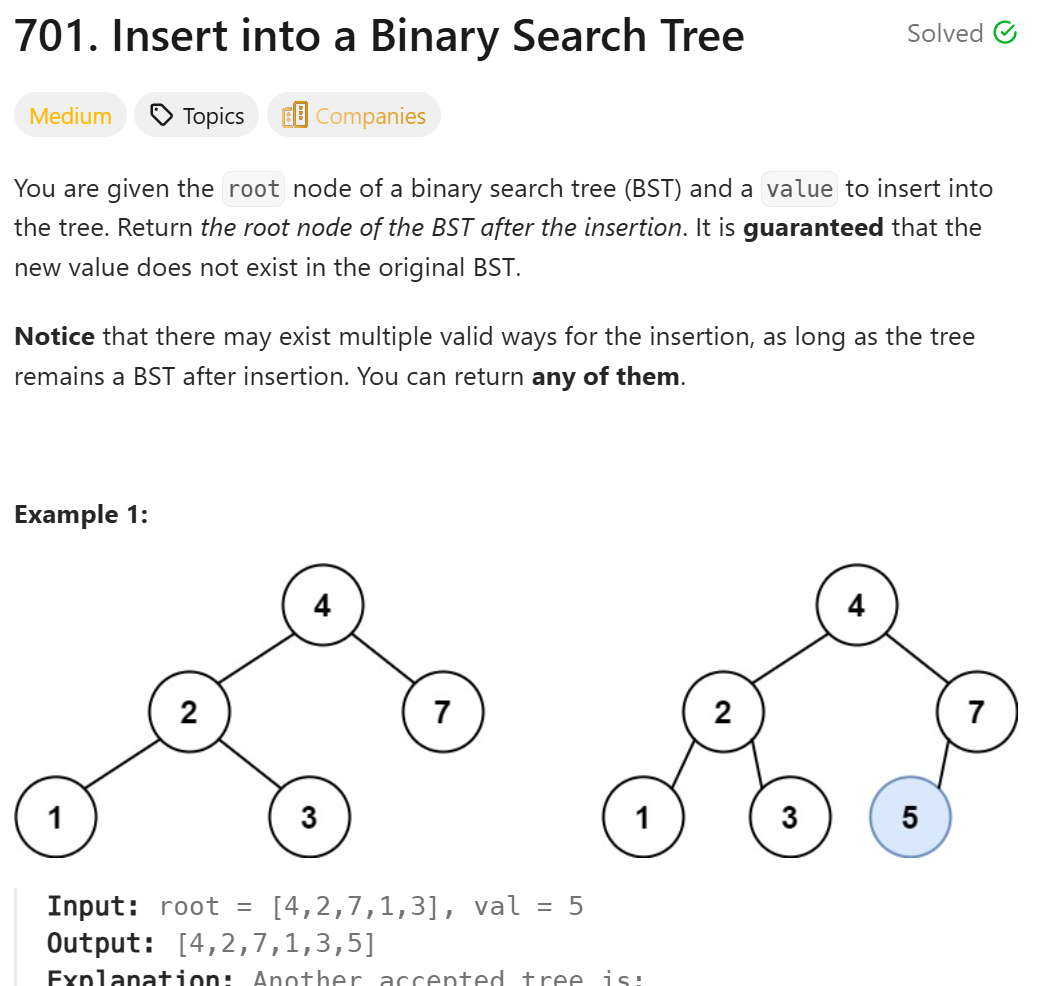
```python
class Solution:
    def insertIntoBST(self, root: Optional[TreeNode], val: int) -> Optional[TreeNode]:
        if not root:
            root = TreeNode(val)
            return root
        
        def dfs(node):
            if not node:
                return 
            
            if val < node.val:
                if node.left:
                    dfs(node.left)
                else:
                    node.left = TreeNode(val)
                    
            if val > node.val:
                if node.right:
                    dfs(node.right)
                else:
                    node.right = TreeNode(val)
                    
            return
        
        dfs(root)
        return root
``` 

# Deletion in a BST

According to the number of its children, we should consider three different cases:

1. If the target node has no child, we can simply remove the node.
2. If the target node has one child, we can use its child to replace itself.
3. If the target node has two children, replace the node with its in-order successor or predecessor node and delete that node.

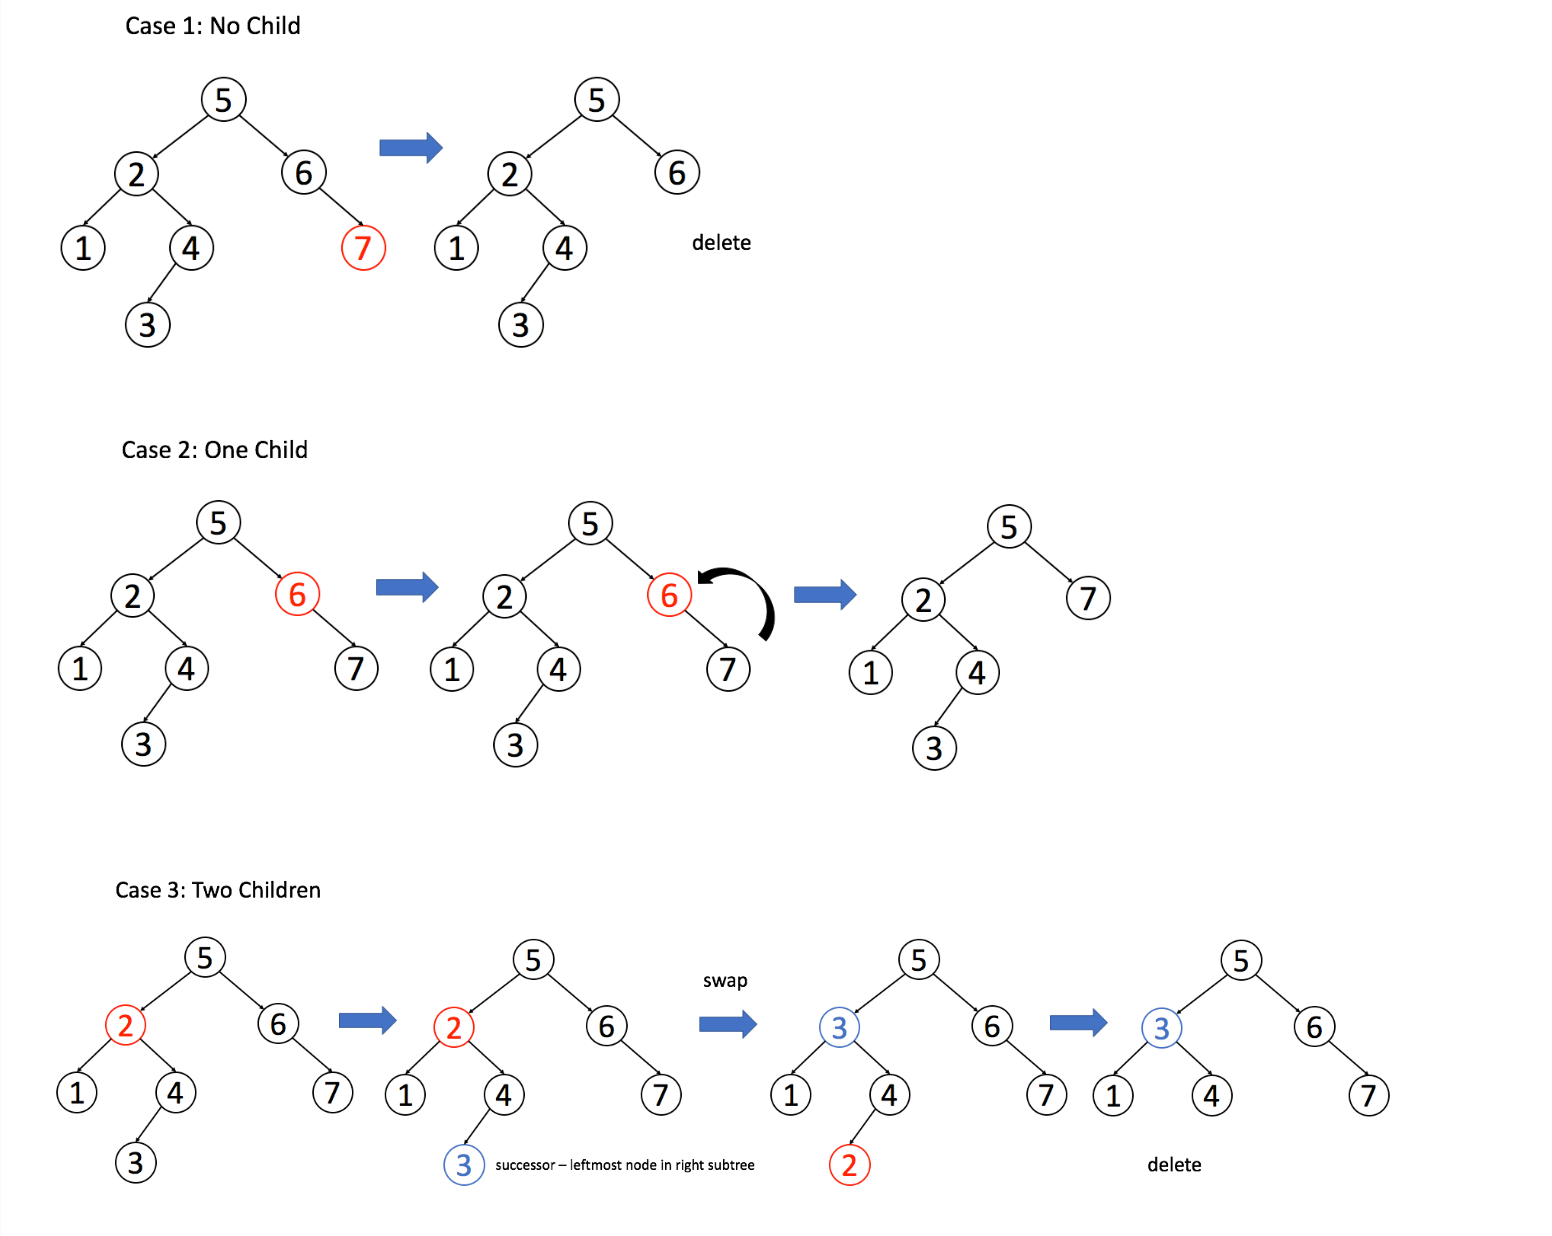

# Delete Node in BST
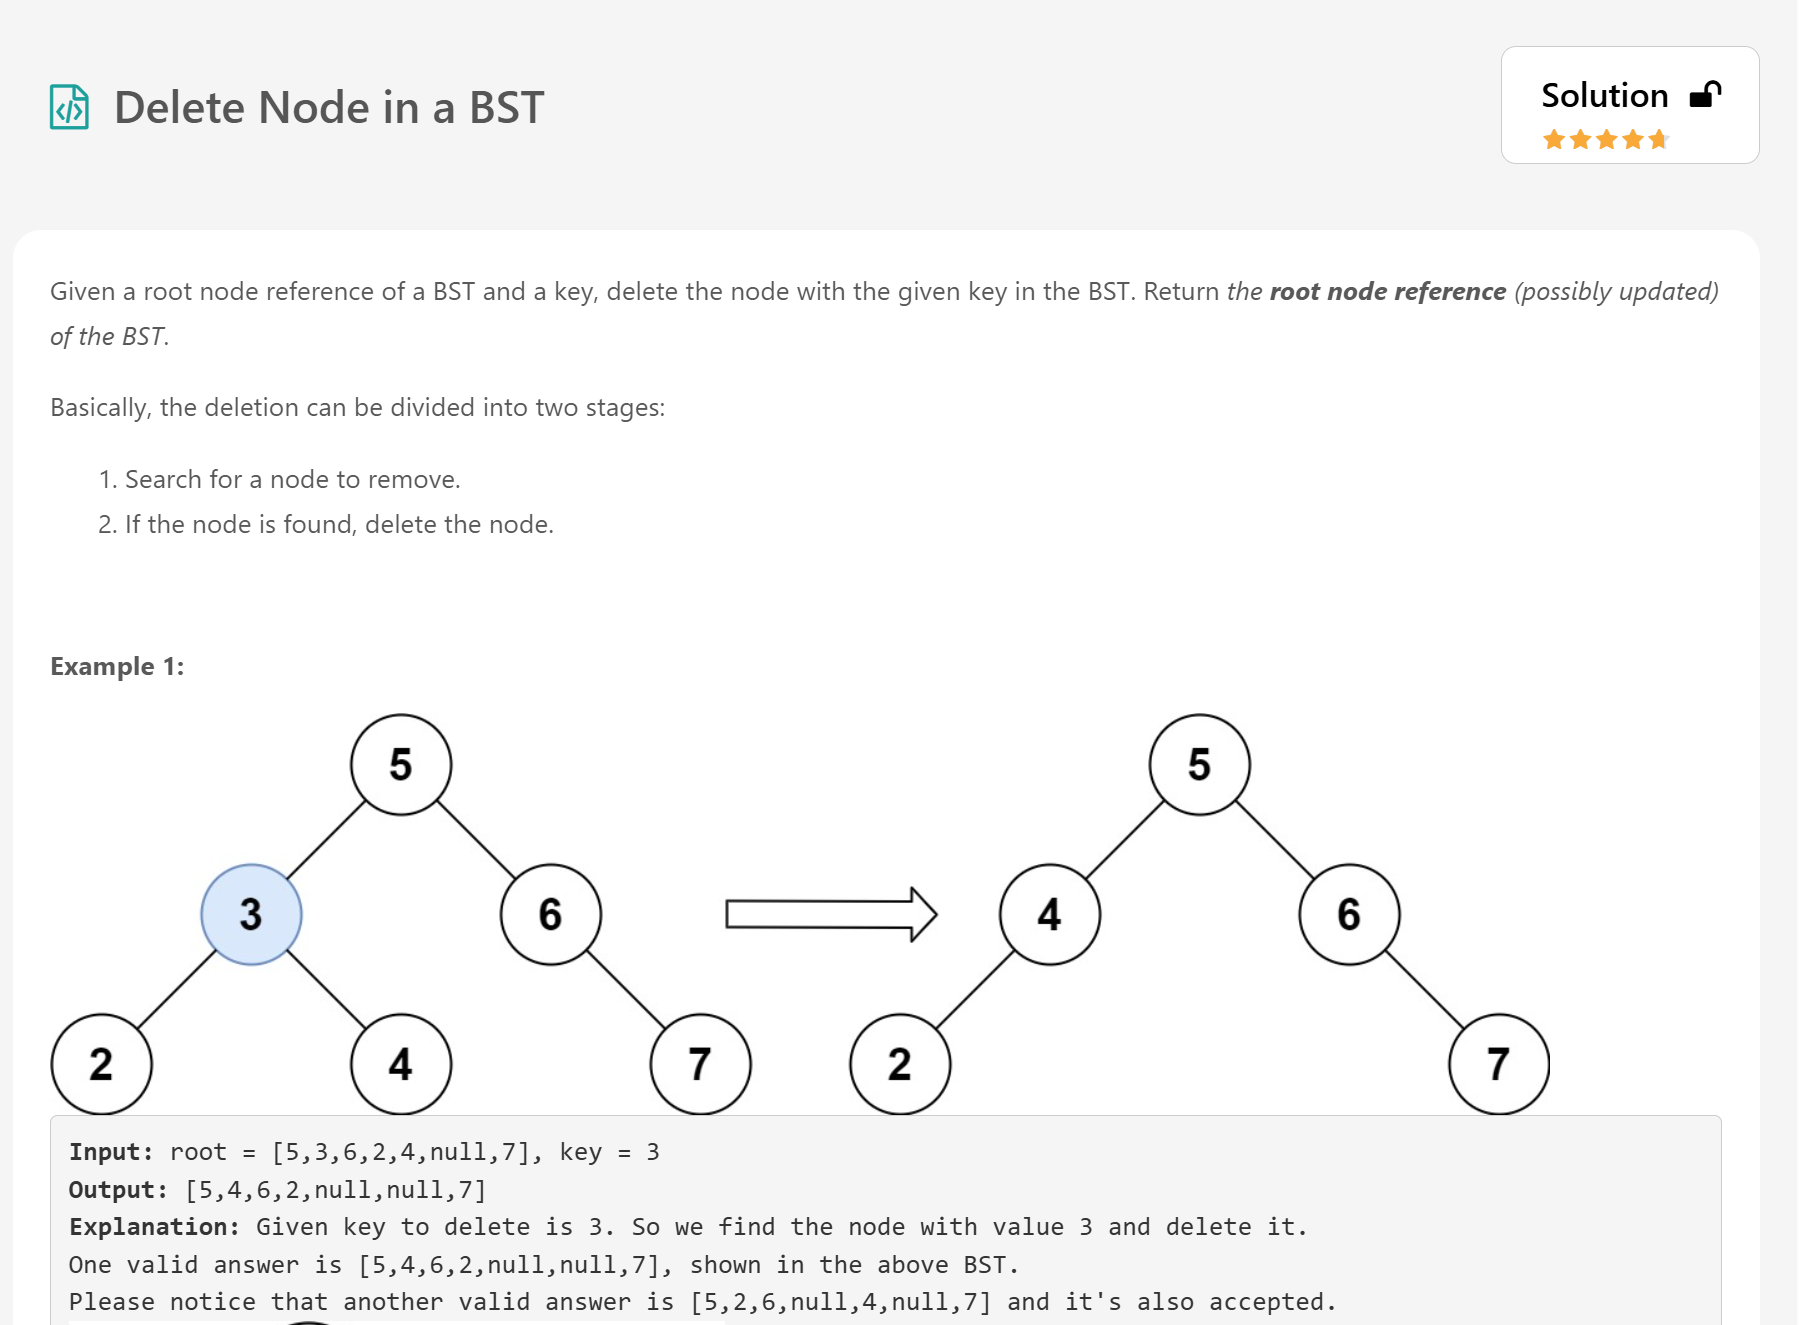
```python
class Solution:
    def deleteNode(self, root: Optional[TreeNode], key: int) -> Optional[TreeNode]:
        def dfs(root):
            if not root:
                return None

            if key < root.val:
                root.left = dfs(root.left)

            elif key > root.val:
                root.right = dfs(root.right)

            else:
                if not root.left:
                    return root.right

                if not root.right:
                    return root.left

                successor = root.right
                while successor.left:
                    successor = successor.left

                root.val, successor.val = successor.val, root.val
                root.right = dfs(root.right)

            return root

        return dfs(root)
```

# **统一模版**
```python
def dfs(node, target):
    if not node:
        return base_case
    
    if target < node.val:
        node.left = dfs(node.left, target)
    elif target > node.val:
        node.right = dfs(node.right, target)
    else:
        # 找到目标节点后做对应操作
        ...
    
    return node
```



# **BST Operations Template**

## Search
```python
def search(root, target):
    if not root:
        return None
    
    if target == root.val:
        return root
    elif target < root.val:
        return search(root.left, target)
    else:
        return search(root.right, target)
```

## Insert
```python
def insert(root, val):
    if not root:
        return TreeNode(val)
    
    if val < root.val:
        root.left = insert(root.left, val)
    elif val > root.val:
        root.right = insert(root.right, val)
    
    return root
```

## Delete
```python
def delete(root, key):
    if not root:
        return None
    
    if key < root.val:
        root.left = delete(root.left, key)
    elif key > root.val:
        root.right = delete(root.right, key)
    else:
        if not root.left:
            return root.right
        if not root.right:
            return root.left
        
        successor = root.right
        while successor.left:
            successor = successor.left
        
        root.val = successor.val
        root.right = delete(root.right, successor.val)
    
    return root
```

# Lowest Common Ancestor in a BST
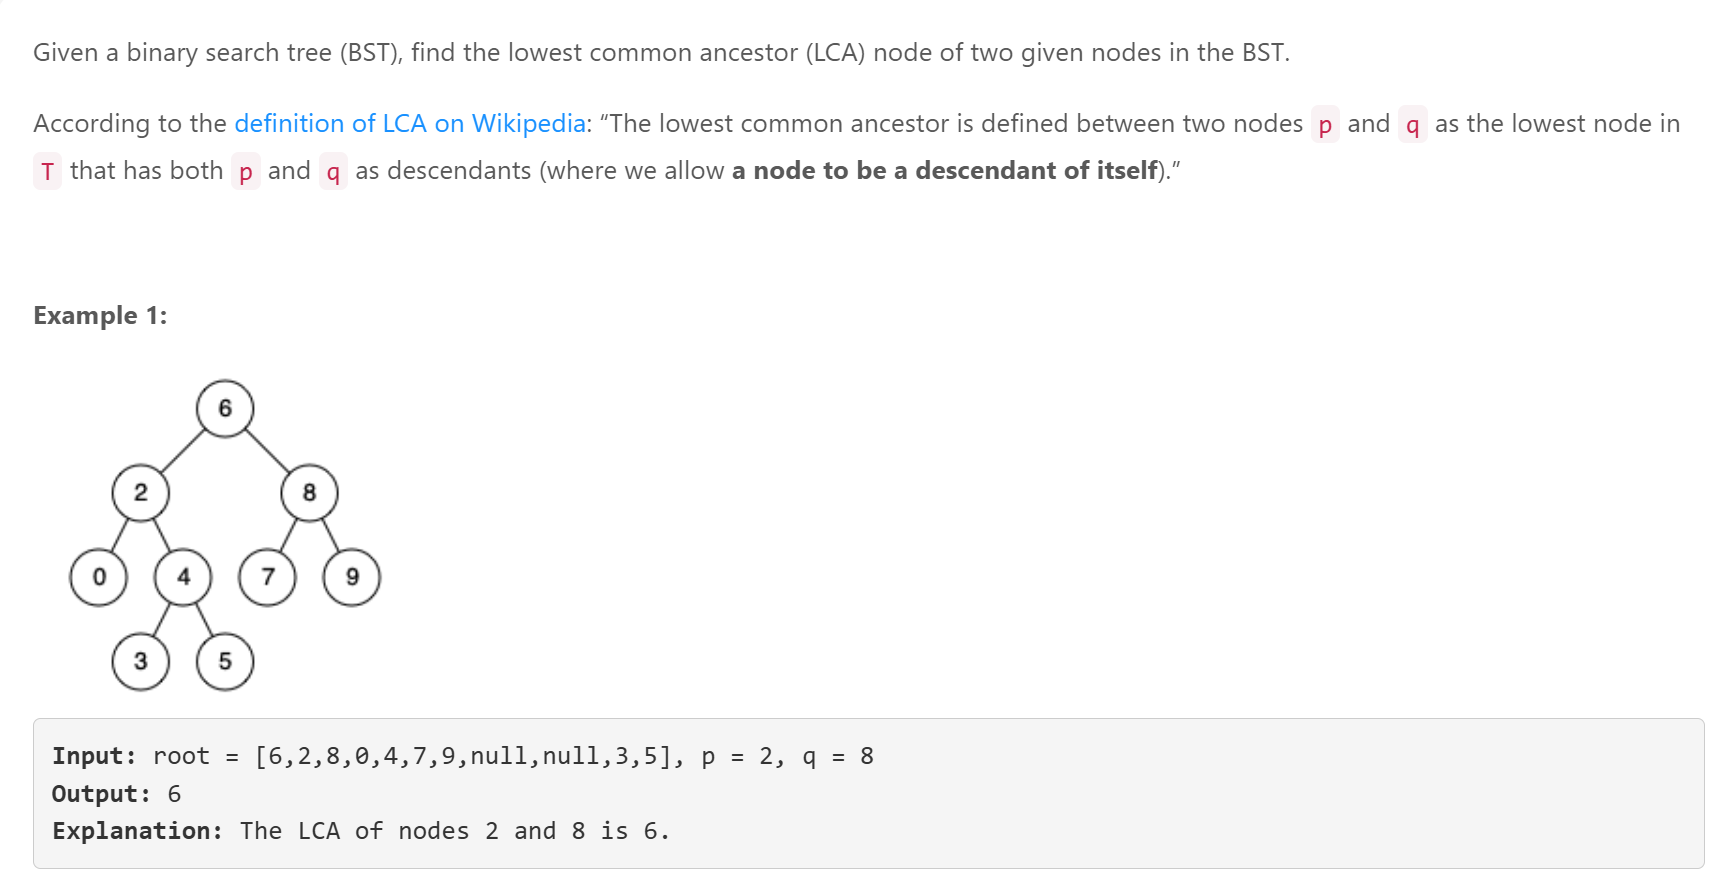
```python
class Solution:
    def lowestCommonAncestor(self, root: 'TreeNode', p: 'TreeNode', q: 'TreeNode') -> 'TreeNode':
        while root:
            if p.val < root.val and q.val < root.val:
                root = root.left
            elif p.val > root.val and q.val > root.val:
                root = root.right
            else:
                return root
```

# Convert Sorted Array to Binary Search Tree
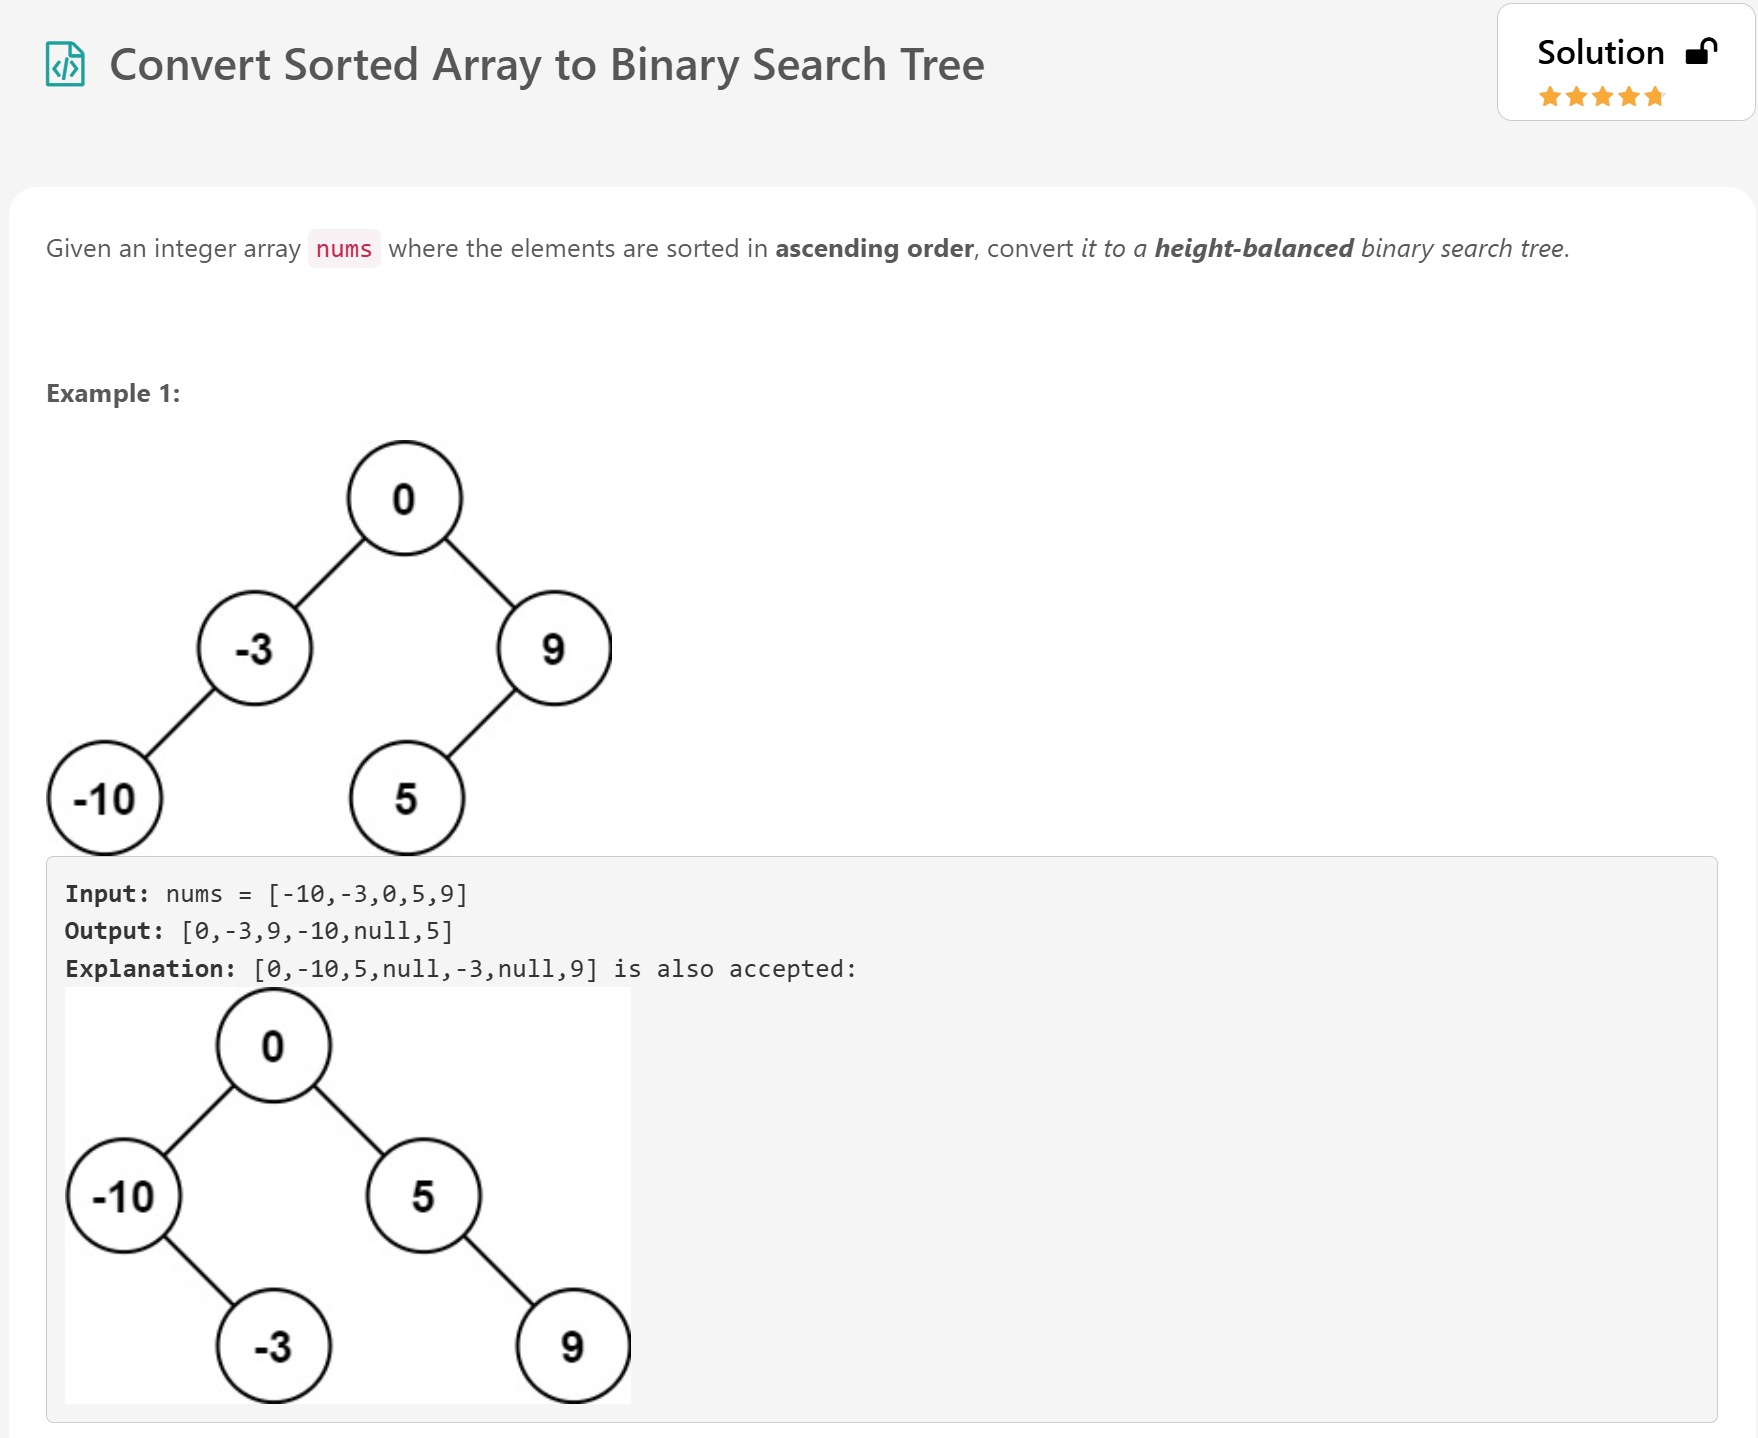

```python
class Solution:
    def sortedArrayToBST(self, nums: List[int]) -> Optional[TreeNode]:
        def convert(l,r):
            if l > r:
                return None
            
            mid = (l+r)//2

            node = TreeNode(nums[mid])

            node.left = convert(l,mid-1)
            node.right = convert(mid+1,r)

            return node

        root_node = convert(0,len(nums) - 1)
        return root_node
```

# Search in Trie

1. Initialize: cur = root
2. for each char c in target string S:
3.   if cur does not have a child c:
4.     search fails
5.   cur = cur.children[c]
6. search successes

# Insertion in Trie

1. Initialize: cur = root
2. for each char c in target string S:
3.      if cur does not have a child c:
4.          cur.children[c] = new Trie node
5.      cur = cur.children[c]
6. cur is the node which represents the string S

# Applications

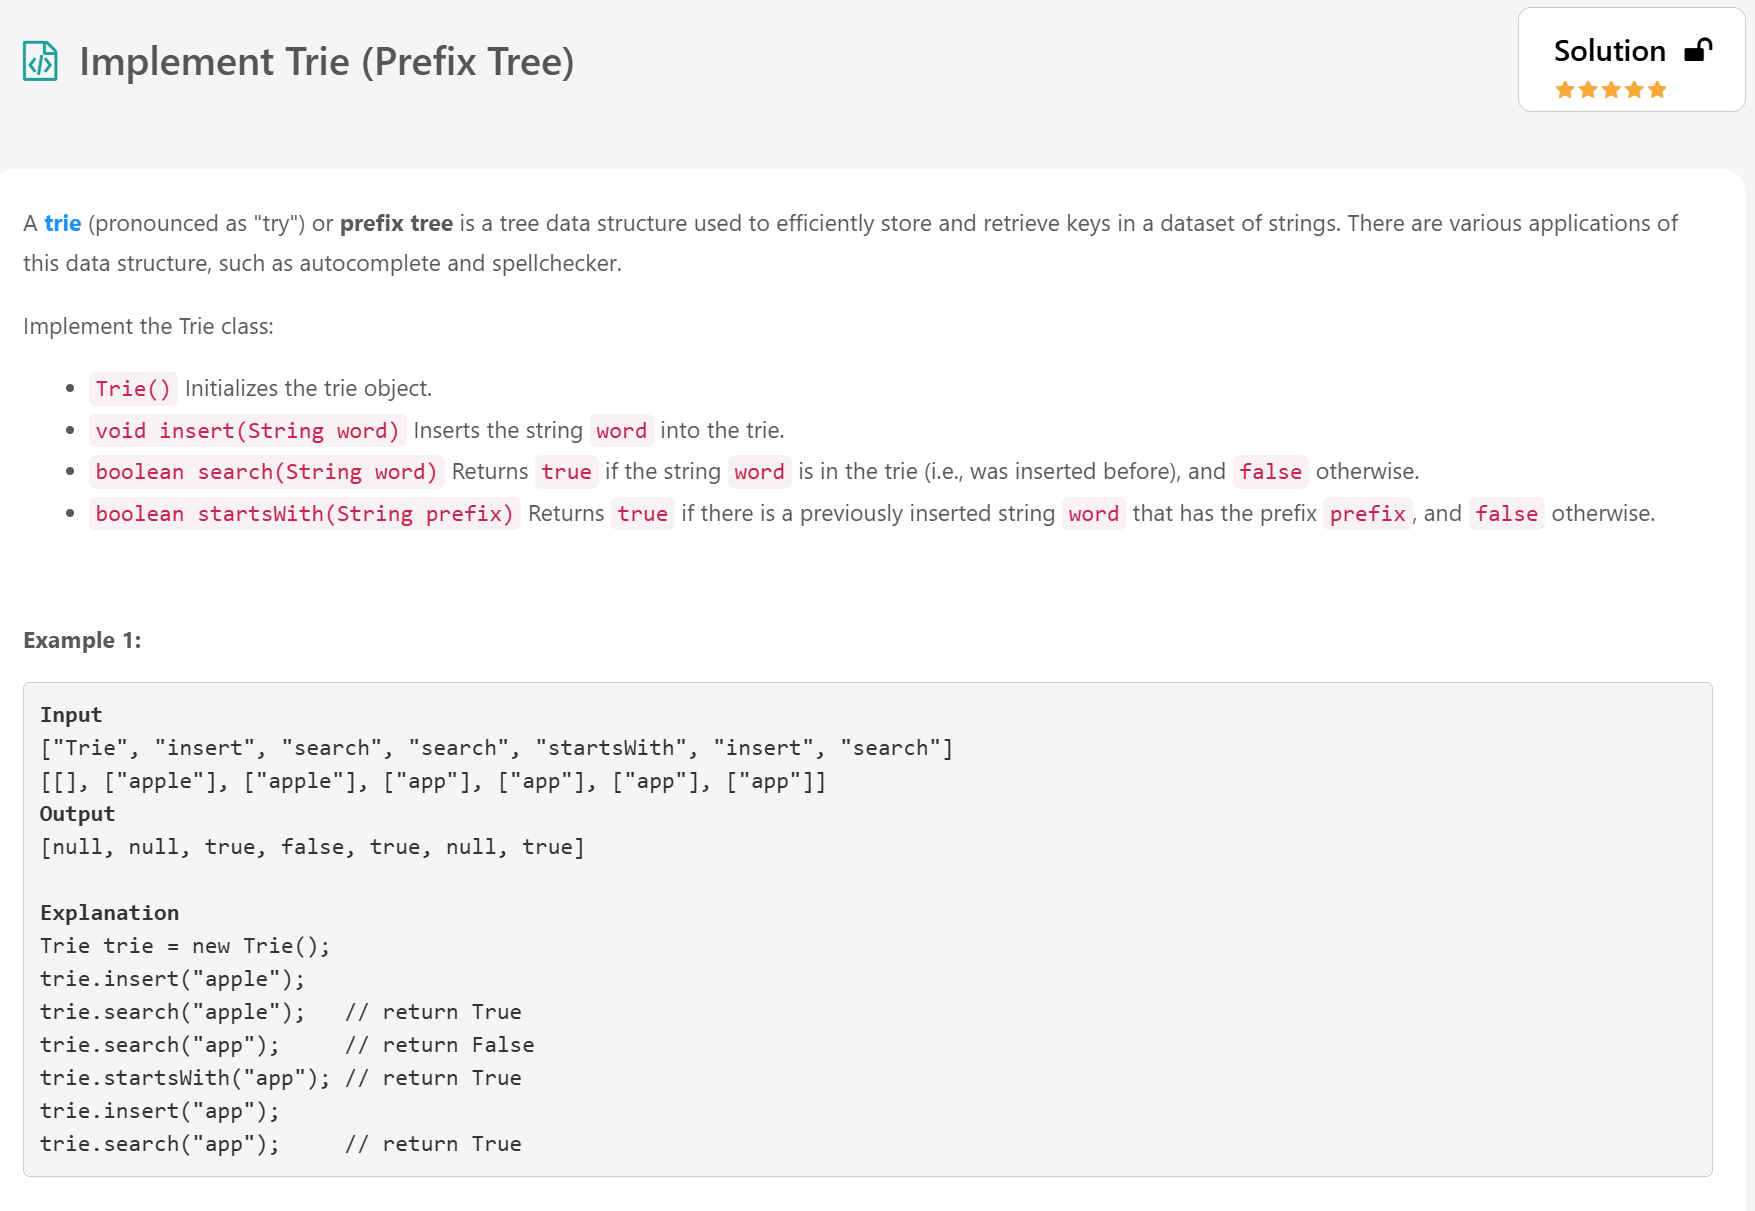

```python
class TreeNode:
    def __init__(self, val = None):
        self.val = val
        self.children = {}
        
class Trie(object):

    def __init__(self):
        self.root = TreeNode("#")
        self.trie = [self.root]
        

    def insert(self, word):
        """
        :type word: str
        :rtype: None
        """
        root = self.root
        for char in word:
            if char not in root.children:
                root.children[char] = TreeNode(char)
            root = root.children[char]
            
        root.children["#"] = TreeNode("#")
            
        

    def search(self, word):
        """
        :type word: str
        :rtype: bool
        """
        root = self.root
        for char in word:
            if char not in root.children:
                return False
            root = root.children[char]
                
        return True if "#" in root.children else False
        

    def startsWith(self, prefix):
        """
        :type prefix: str
        :rtype: bool
        """
        root = self.root
        for char in prefix:
            if char not in root.children:
                return False
            root = root.children[char]
                
        return True
```


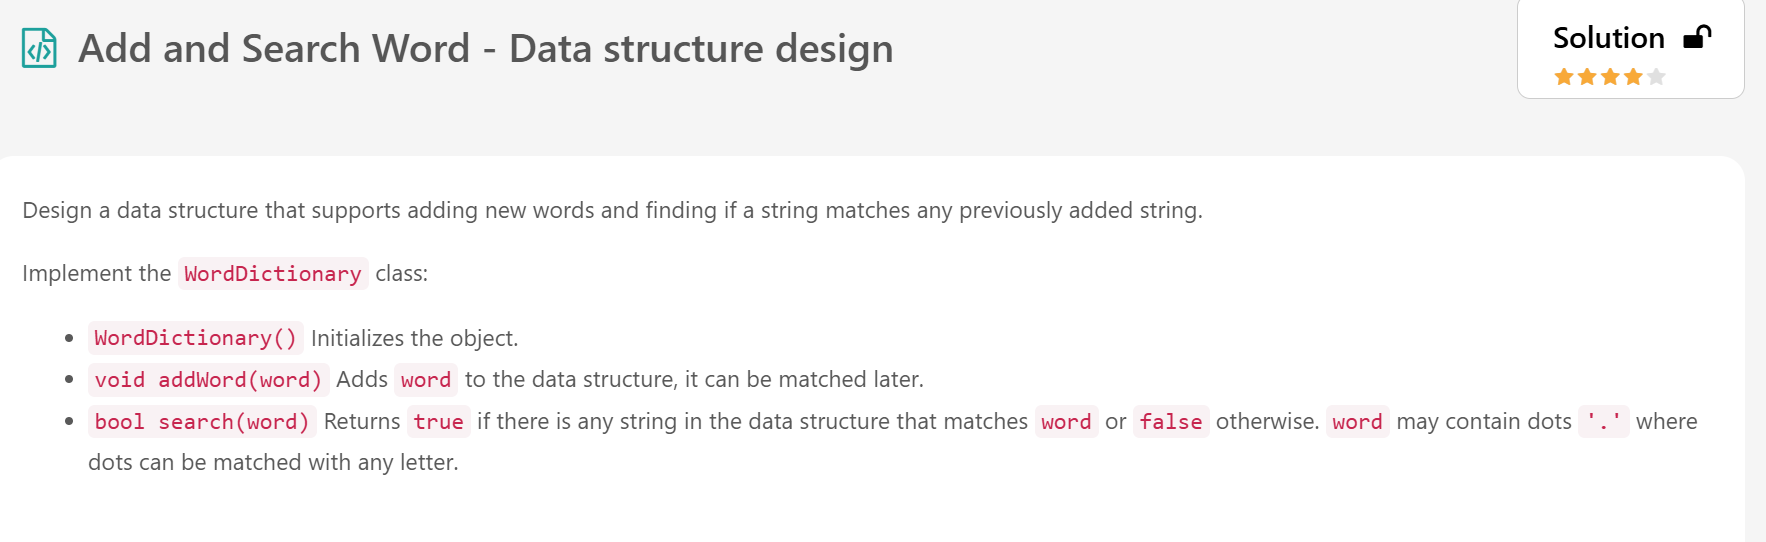

```python
class TrieNode:
    def __init__(self):
        self.flag = False
        self.children = {}
        
class WordDictionary(object):

    def __init__(self):
        self.root = TrieNode()
        

    def addWord(self, word):
        """
        :type word: str
        :rtype: None
        """
        root = self.root
        
        for char in word:
            if char not in root.children:
                root.children[char] = TrieNode()
            root = root.children[char]
            
        root.flag = True
        
        return
        

    def search(self, word):
        """
        :type word: str
        :rtype: bool
        """
        def dfs(i, node):
            if i == len(word):
                return node.flag
            
            char = word[i]
            
            if char == ".":
                for child in node.children:
                    if dfs(i+1,node.children[child]):
                        return True
                return False
            
            else:
                if char not in node.children:
                    return False
                return dfs(i+1,node.children[char])
            
        return dfs(0,self.root)

```